In [240]:
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats import oneway
import statsmodels.api as sm
#import scikit_posthocs as sp
import pingouin

# Načtení dat ze souboru 


In [241]:
aku = pd.read_csv('aku.csv', sep=';', index_col=0) #sep: oddělovač, index_col: číslo sloupce s indexem řádku (soubor jej nemusí obsahovat)

In [242]:
aku

,vyrobce,kapacita_5,kapacita_100
cislo,,,
1,A,1996,1717
2,A,2053,2134
3,A,2087,1981
4,A,2026,1834
5,A,2039,1941
...,...,...,...
124,D,2039,1795
125,D,2021,1948
126,D,2070,1858


In [243]:
aku.columns # názvy slupců v datovém souboru

Index(['vyrobce', 'kapacita_5', 'kapacita_100'], dtype='str')

In [244]:
aku.head() # výpis prvních řádků souboru

,vyrobce,kapacita_5,kapacita_100
cislo,,,
1,A,1996,1717
2,A,2053,2134
3,A,2087,1981
4,A,2026,1834
5,A,2039,1941


In [245]:
aku['vyrobce'].dtype # data ve slpupci jsou v obecného typu "object"

<StringDtype(storage='python', na_value=nan)>

In [246]:
# sloupec lze převést na typ Category
aku['vyrobce']=aku['vyrobce'].astype('category')
# pro data typu Category můžeme zvolit vlastní pořadí kategorií (hodnot) 
aku['vyrobce']=aku['vyrobce'].cat.as_ordered() 
aku['vyrobce']=aku['vyrobce'].cat.reorder_categories(['C', 'B', 'A', 'D'])

In [247]:
aku['vyrobce'] # v posledním řádku vidíme, že kategorie jsou uspořádány podle zadaného pořadí

cislo
1      A
2      A
3      A
4      A
5      A
      ..
124    D
125    D
126    D
127    D
128    D
Name: vyrobce, Length: 128, dtype: category
Categories (4, str): ['C' < 'B' < 'A' < 'D']

# Explorační analýza

## Explorační analýza kategoriální proměnné

In [248]:
# četnosti výskytu jednotlivých kategorií
aku['vyrobce'].value_counts()

vyrobce
C    32
B    32
A    32
D    32
Name: count, dtype: int64

<Axes: >

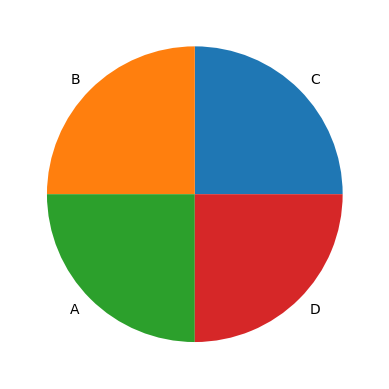

In [249]:
# koláčový graf
aku['vyrobce'].value_counts().plot.pie()

Text(0, 0.5, 'počet akumulátorů')

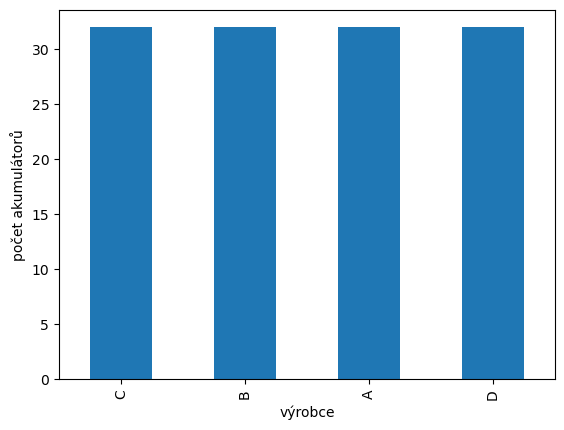

In [250]:
# sloupcový graf
aku['vyrobce'].value_counts().plot.bar()
plt.xlabel("výrobce")
plt.ylabel("počet akumulátorů")

## Explorační analýza kvantitativních proměnných

In [251]:
# základní numerické charakteristiky
aku.describe()

,kapacita_5,kapacita_100
count,128.00000,128.000000
mean,1987.93750,1828.492188
std,142.30309,179.292529
min,732.00000,620.000000
25%,1969.75000,1773.500000
50%,2005.00000,1846.000000
75%,2041.25000,1928.250000
max,2129.00000,2134.000000


In [252]:
(((aku['kapacita_5']-aku['kapacita_5'].mean())**2).sum()/127)**0.5

np.float64(142.30308953546503)

<Axes: ylabel='Frequency'>

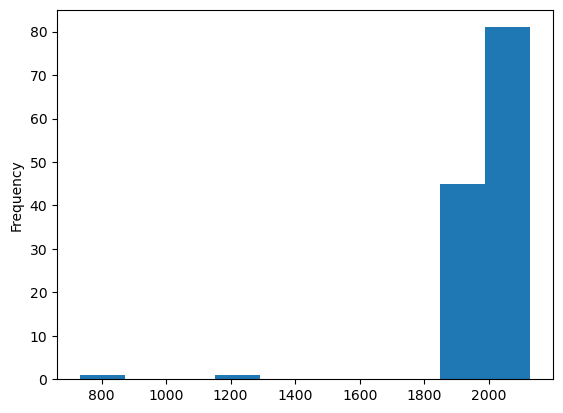

In [253]:
aku['kapacita_5'].plot.hist()

Text(0, 0.5, 'četnost výskytu')

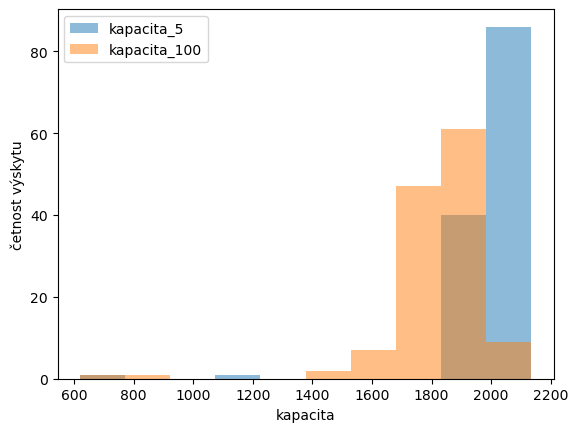

In [254]:
# histogramy
aku.plot.hist(alpha=0.5) 
plt.xlabel("kapacita")
plt.ylabel("četnost výskytu")

Text(0, 0.5, 'kapacita')

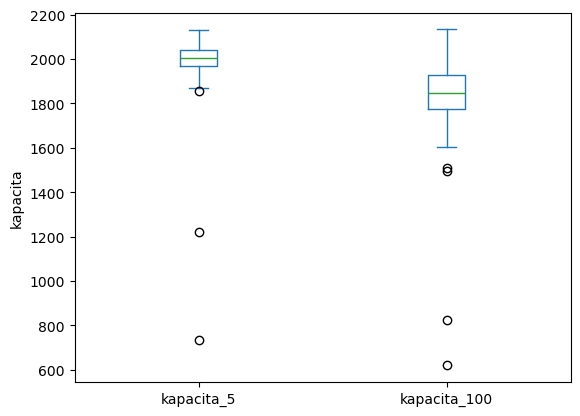

In [255]:
# krabicové grafy
aku.plot.box()
plt.ylabel("kapacita")

In [256]:
# výpis řádků obsahujících odlehlá pozorování ve sloupci kapacit po 5 cyklech  (podle metody vnitřních hradeb)
Q1_5=aku['kapacita_5'].quantile(0.25)
Q3_5=aku['kapacita_5'].quantile(0.75)
IQR_5 = Q3_5-Q1_5
out_5 = (aku['kapacita_5']<(Q1_5-1.5*IQR_5)) | (aku['kapacita_5']>(Q3_5+1.5*IQR_5))
aku[out_5]

,vyrobce,kapacita_5,kapacita_100
cislo,,,
20,A,732,620
33,B,1854,1841
88,C,1221,823


In [257]:
out_5

cislo
1      False
2      False
3      False
4      False
5      False
       ...  
124    False
125    False
126    False
127    False
128    False
Name: kapacita_5, Length: 128, dtype: bool

In [258]:
# ponecháme jen řádky obsahující v obou sloupcích hodnoty nad 1500 mAh (zbylé akumulároty jsou považovány za vadné)
aku = aku[(aku['kapacita_5']>=1500)&(aku['kapacita_100']>=1500)].copy() 

Text(0, 0.5, 'četnost výskytu')

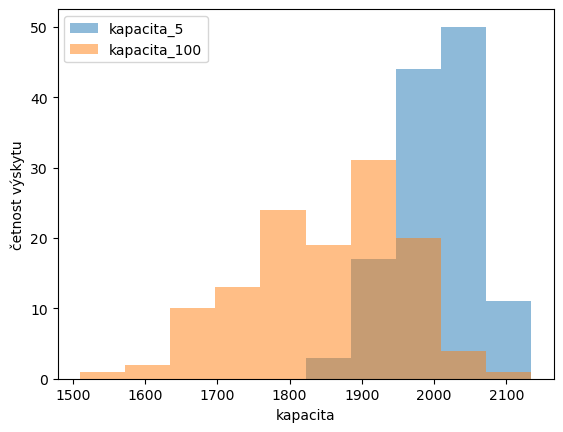

In [259]:
# histogramy po odstranění vadných akumulátorů
aku.plot.hist(alpha=0.5)
plt.xlabel("kapacita")
plt.ylabel("četnost výskytu")

Text(0, 0.5, 'kapacita')

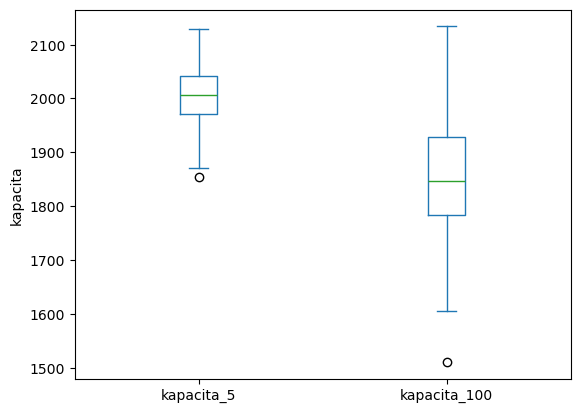

In [260]:
# krabicové grafy po odstranění vadných akumulátorů
aku.plot.box()
plt.ylabel("kapacita")

In [261]:
# základní charakteristiky pro data očištěná od odlehých pozorování
aku.describe()

,kapacita_5,kapacita_100
count,125.000000,125.000000
mean,2004.328000,1848.864000
std,54.768247,108.085341
min,1854.000000,1510.000000
25%,1971.000000,1783.000000
50%,2007.000000,1847.000000
75%,2042.000000,1929.000000
max,2129.000000,2134.000000


## Závislost dvou kvantitativních proměnných

<Axes: xlabel='kapacita_5', ylabel='kapacita_100'>

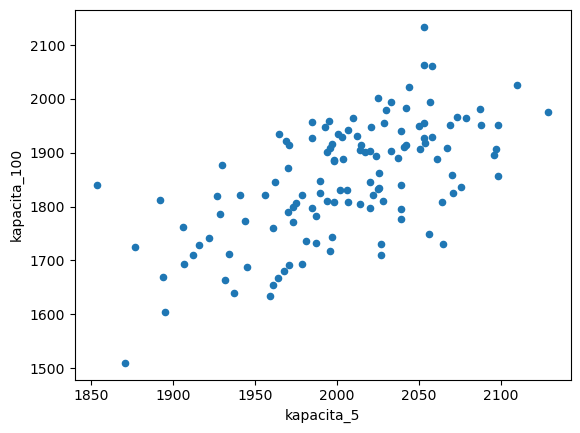

In [262]:
# bodový graf závislosti kapacit po 5 a kapacit po 100 cyklech
aku.plot.scatter(x='kapacita_5', y='kapacita_100')
# z rozložení bodů v grafu lze usoudit, že hodnoty kapacit po 5 a po 100 cyklech jsou vzájemně závislé

In [263]:
# Pearsonvy korelační koeficienty (bodové odhady korelací)
aku.corr(numeric_only=True)

,kapacita_5,kapacita_100
kapacita_5,1.000000,0.621874
kapacita_100,0.621874,1.000000


In [264]:
np.corrcoef(aku['kapacita_5'], aku['kapacita_100']) # totéž pomocí numpy

array([[1.       , 0.6218736],
       [0.6218736, 1.       ]])

## Explorační analýza závislosti kvantitativní a kategoriální proměnné

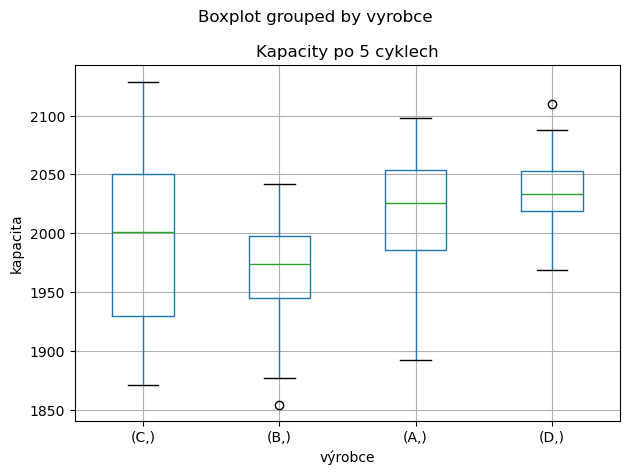

In [265]:
# krabicové grafy kapacit po 5 cyklech v zavislosti na vyrobci
aku.boxplot(column=['kapacita_5'], by=['vyrobce']);
plt.title('Kapacity po 5 cyklech')
plt.xlabel('výrobce')
plt.ylabel('kapacita')
plt.tight_layout() # upravi mezery kolem grafu
# výrazné posunutí krabicových grafů (např. B proti D) naznačuje závislost kapacity po 5 cyklech na výrobci

## Explorační analýza závislosti dvou kategoriálních proměnných

In [266]:
# pokles kapacit mezi 5. a 100. cyklem (přidáme jako další sloupec datového rámce)
aku['pokles']=aku['kapacita_5']-aku['kapacita_100']

In [267]:
# relativní pokles
aku['rel_pokles']=aku['pokles']/aku['kapacita_5']

In [268]:
# je relativní pokles > 0.1 ?
aku['pokles_nad10p'] = aku['rel_pokles']>0.1

In [269]:
aku

,vyrobce,kapacita_5,kapacita_100,pokles,rel_pokles,pokles_nad10p
cislo,,,,,,
1,A,1996,1717,279,0.139780,True
2,A,2053,2134,-81,-0.039454,False
3,A,2087,1981,106,0.050791,False
4,A,2026,1834,192,0.094768,False
5,A,2039,1941,98,0.048063,False
...,...,...,...,...,...,...
124,D,2039,1795,244,0.119667,True
125,D,2021,1948,73,0.036121,False
126,D,2070,1858,212,0.102415,True


In [270]:
# kontingenční tabulka (tabulka absolutních četností dvojic (výrobce, pokles > 0.1))
crt = pd.crosstab(aku['vyrobce'], aku['pokles_nad10p'])

In [271]:
crt

pokles_nad10p,False,True
vyrobce,,
C,17,14
B,27,5
A,16,14
D,29,3


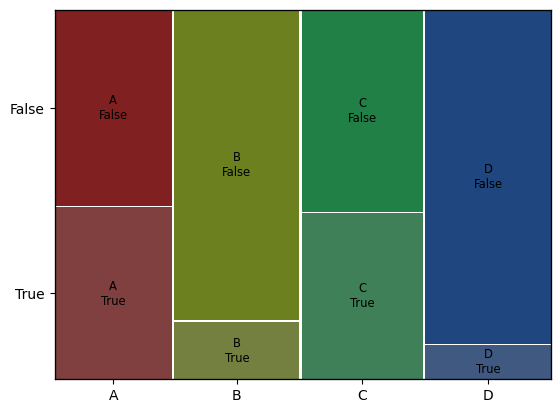

In [272]:
# mozaikový graf (grafické znázornění kontingeční tabulky)
mosaic(aku, ['vyrobce', 'pokles_nad10p']);
# výrazně rozdílné poměry výšek buněk v jednotlivých sloupcích nazačují závislsot mezi poklesem a výrobcem

## Ověření normality 

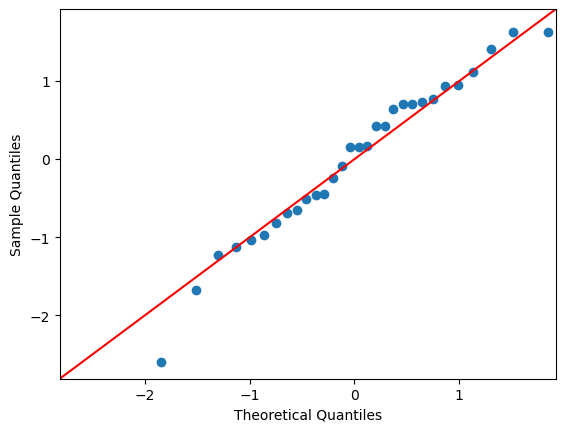

In [273]:
# pomocí QQ grafu
sm.qqplot(aku['kapacita_5'][aku['vyrobce']=='A'], line='45', fit=True)
plt.show()
# rozložení bodů podél přímky ukazuje na normální rozdělení dat

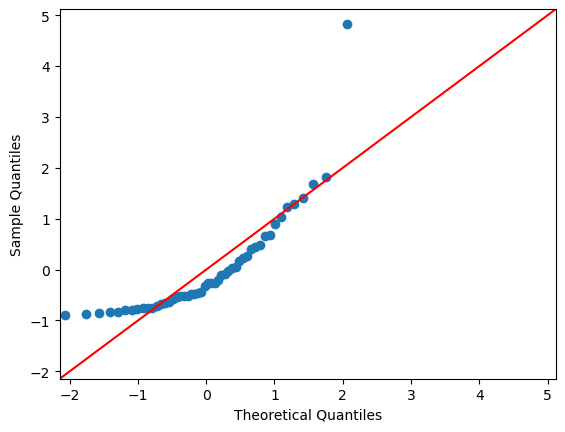

In [274]:
# Obdobný graf pro data zexponenciálního rozdělení ukazuje výrazný odklad od přímky. Z toho lze usuzovat, že data nemají normální rozdělení.
x = np.random.exponential(5, size=50)
sm.qqplot(x, line='45', fit=True)
plt.show()

In [275]:
# normalitu lze testovat např. Shapirovým-Wilkovým testem (H0: data mají normální rozdělení, H1: data nemají normální rozdělení)
stats.shapiro(aku['kapacita_5'][aku['vyrobce']=='A'])
# vyspoká p-hodnota ukazuje, že data nevykazují významnou odchylku od normality 

ShapiroResult(statistic=np.float64(0.9714747135297213), pvalue=np.float64(0.5802689901903145))

# Testy hypotéz, intervalové odhady

## Ověření normality pro jednotlivé kapacity a výrobce

In [276]:
aku[['kapacita_5', 'vyrobce']].groupby('vyrobce').apply(stats.shapiro)

vyrobce
C     (0.965865408829236, 0.41305170799709096)
B    (0.9383654587698599, 0.06729146072241271)
A     (0.9714747135297213, 0.5802689901903145)
D      (0.9861743821411898, 0.945940330546081)
dtype: object

In [277]:
aku[['kapacita_100', 'vyrobce']].groupby('vyrobce').apply(stats.shapiro)

vyrobce
C    (0.9675898790005942, 0.4552957838589469)
B    (0.9734574692845183, 0.5997473889779995)
A    (0.9716189224770585, 0.5843604883650215)
D    (0.9814876965330716, 0.8415135456873882)
dtype: object

Všechny p-hodnoty jsou vyšší než 0.05. Jednotlivé výběry můžeme považovat za výbery z normálního rozdělení.

## Jednovýběrový t-test (test střední hodnoty v normálním rozdělení)

Dosahují akumulátory výrobce A po 5 cyklech deklarované kapacity?

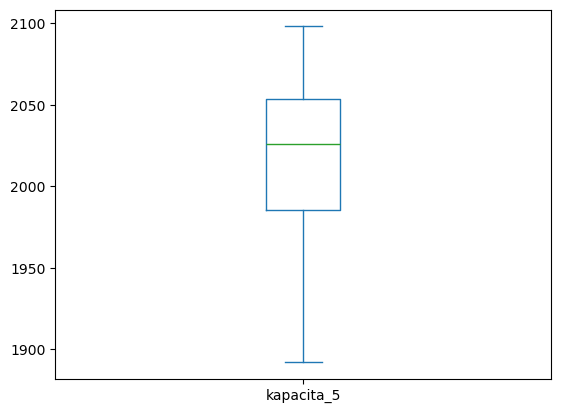

In [278]:
kap5A = aku['kapacita_5'][aku['vyrobce']=='A']
kap5A.plot.box();
# krabicový graf nenaznačuje výraznou odchylku od deklarované hodnoty

Testujeme $H_0$: $\mu_A=2000$ proti $H_1$: $\mu_A\neq 2000$

In [279]:
# oboustranný jednovýběrový t-test
result = stats.ttest_1samp(kap5A, popmean=2000)
print("Jednovýběrový t-test: p-hodnota={:f}".format(result.pvalue))

Jednovýběrový t-test: p-hodnota=0.048518


Na hladině významnosti 0.05 zamítáme $H_0$. Střední hodnota kapacit akumumulátorů výrobce A po 5 cyklech vykazuje statisticky význanou odchylku od deklarované kapacity.

In [280]:
# jednostranný jednovýběrový t-test H0: \mu_A=2000, H1: \mu_A>2000
result = stats.ttest_1samp(kap5A, popmean=2000, alternative='greater')
print("Jednovýběrový t-test: p-hodnota={:f}".format(result.pvalue))
# pro H1: \mu_A<2000 ... alternative='less'
# pro H1: \mu_A<>2000 ... alternative='two-sided' (výchozí hodnota parametru)

Jednovýběrový t-test: p-hodnota=0.024259


---

## Dvouvýběrový t-test (test rovnosti středních hodnot vzájemně neávislých výběrů z normálních rozdělení)

Liší se střední hodnoty kapacit akumulátorů výrobců B a D po 100 cyklech?

In [281]:
kapB100 = aku['kapacita_100'][aku['vyrobce']=='B']
kapD100 = aku['kapacita_100'][aku['vyrobce']=='D']

Text(0, 0.5, 'kapacita')

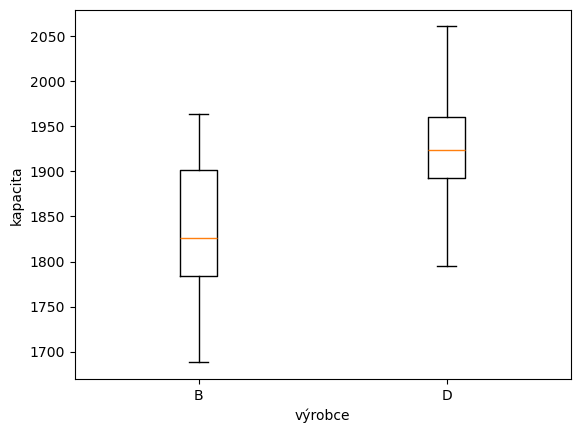

In [282]:
# krabicové grafy pomocí matplotlib
plt.boxplot([kapB100, kapD100])
plt.xticks(ticks=[1, 2], labels=['B', 'D'])
plt.xlabel('výrobce')
plt.ylabel('kapacita')

Krabicové grafy naznačují, že kapacity akamulátorů výrobce D jsou vyšší než výrobce B. Proto volíme jednostrannou alternativní hypotézu.

Krabicové grafy nenaznačjí rozdíl v rozptylech. Použijeme jednostranný t-test pro výběry se shodnými rozptyly.

Test $H_0$: $\mu_B=\mu_D$ proti $H_1$: $\mu_B<\mu_D$

In [283]:
# dvouvýběrový t-test
test = stats.ttest_ind(kapB100, kapD100, equal_var=True)       # pro rozdílné rozptyly: equal_var=False
print("Dvouvýběrový t-test: p-hodnota={:f}".format(test.pvalue))

Dvouvýběrový t-test: p-hodnota=0.000003


Na hladině významnosti 0.05 zamítáme $H_0$. Střední hodnoty kapacit po 100 cyklech akumulátorů výrobce D jsou vyšší než střední hodnoty kapacit akumulátorů výrobce B.

---

## Test shody rozptylů pro dva výběry z normálních rozdělení

Liší se rozptyly hodnoty kapacit akuamulátorů výrobců B a D po 100 cyklech?

$H_0$: $\sigma_B^2=\sigma_D^2$, $H_1$: $\sigma_B^2>\sigma_D^2$

In [284]:
# test rovnosti rozptylů není dostupný v použitých knihovnách, provedeme jej ručně
SB100 = kapB100.var()
SD100 = kapD100.var()
F = SB100/SD100
pval = 1-stats.f.cdf(F, len(kapB100)-1, len(kapD100)-1)
print("F-test: p-hodnota={:f}".format(pval))


F-test: p-hodnota=0.225281


Na hladině významnosti 0.05 nezamítáme $H_0$. U akamulátorů výrobců B a D nebyl po 100 cyklech prokázán rozdíl v rozptylech kapacit.

---

## Párový t-test (test rovnosti středních hodnot pro párová data)

Liší se kapacity akumulátorů výrobce A po 5 a po 100 cyklech?

__POZOR__: Nejde o nezávislé výběry! Data jsou párová. Měření kapacit po 5 a po 100 cyklech je prováděno se stejnými akumulátory. Lze očekávat, že kapacity po 5 a po 100 cyklech budou u každého akmulátoru závislé. Posuzujeme stř. hodnotu rozdílů po 5 a po 100 cyklech. 


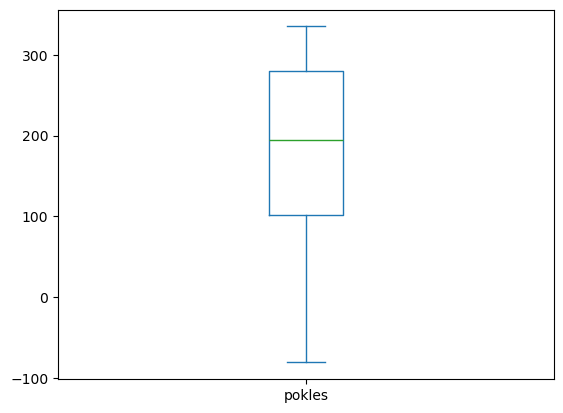

In [285]:
aku['pokles'][aku['vyrobce']=='A'].plot.box();

Krabicový graf ukazuje, že pokles kapacity u výrobce A je výrazně vyšší než 0. 

Ověření normality poklesu kapacit Shapirovým-Wilkovým testem.

In [286]:
stats.shapiro(aku['pokles'])

ShapiroResult(statistic=np.float64(0.991237755428022), pvalue=np.float64(0.6199904409356758))

Hypotézu o normalitě nezamítáme. Poklesy kapacit mají normální rozdělení. Pro test stř. hodnoty poklesu použijeme t-test.

Označme střední hodnotu poklesu kapacity jako $\mu_{pA}$.

Testujeme $H_0$: $\mu_{pA}=0$ proti $H_1$: $\mu_{pA}>0$.

In [287]:
# Chybně (jako nezávislá data):
stats.ttest_ind(aku['kapacita_5'][aku['vyrobce']=='A'], aku['kapacita_100'][aku['vyrobce']=='A'])

TtestResult(statistic=np.float64(7.402334821424309), pvalue=np.float64(6.177663764963664e-10), df=np.float64(58.0))

In [288]:
# Správně pomocí párového t-testu (jako párová data):
stats.ttest_rel(aku['kapacita_5'][aku['vyrobce']=='A'], aku['kapacita_100'][aku['vyrobce']=='A'])

TtestResult(statistic=np.float64(9.260380518227795), pvalue=np.float64(3.66212300123264e-10), df=np.int64(29))

In [289]:
# Správně pomocí jednovýběrového t-testu poklesů:
stats.ttest_1samp(aku['pokles'][aku['vyrobce']=='A'], popmean=0)


TtestResult(statistic=np.float64(9.260380518227795), pvalue=np.float64(3.66212300123264e-10), df=np.int64(29))

In [290]:
result = stats.ttest_rel(aku['kapacita_5'][aku['vyrobce']=='A'], aku['kapacita_100'][aku['vyrobce']=='A'])
print("párový t-test: p-hodnota={:.10f}".format(result.pvalue))


párový t-test: p-hodnota=0.0000000004


Na hladině významnosti 0.05 zamítáme $H_0$. U akamulátorů výrobce A dochází mezi 5 a 100 cyklem k poklesu stř. hodnoty kapacity.

---

## Intervalový odhad střední hodnoty výběru z normálního rozdělení

Intervalové odhady stř. hodot kapacit po 5 cyklech

In [291]:
# ruční výpočet intervalového odhadu  
alfa = 0.05
print('95% intervalové odhady stř. hodnot kapacit po 5 cyklech')
for v in aku['vyrobce'].unique():
    aku_v =  aku['kapacita_5'][aku['vyrobce']==v]  
    m = aku_v.mean() # výběrový průměr
    s = aku_v.std()  # výběrová směrodatná odchylka
    n = len(aku)
    t = stats.t.ppf(1-alfa/2, n-1)  # 1-alfa/2 kvantil studentova rozdělení
    d = t*s/n**0.5 # polovina délky konfidenčního intervalu
    td = m-d # dolní mez
    th = m+d # horn9 mez
    print('výrobce {}: ({:.0f}, {:.0f}) mAh'.format(v, td, th))

95% intervalové odhady stř. hodnot kapacit po 5 cyklech
výrobce A: (2010, 2027) mAh
výrobce B: (1962, 1977) mAh
výrobce C: (1984, 2009) mAh
výrobce D: (2028, 2039) mAh


## ANOVA (test rovnosti stř. hodnot více výběrů z normálních rozdělení)

In [292]:
sloupec = 'pokles' # sloupec s daty pro ANOVu
vyrobci = aku.vyrobce.values.unique()  # hodnoty vysvětlující kategoriální proměnné 
#sloupce = [np.array(aku[sloupec][aku['vyrobce']==v], dtype=float) for v in vyrobci]  # seznam posloupností s hodnotami v jednotlivych sloupcich
#vyrobci = [v for v in aku.groupby('vyrobce')['vyrobce']]
sloupce = [np.array(aku[aku['vyrobce']==v][sloupec], dtype=np.float64) for v in vyrobci]

### Explorační analýza

Text(0, 0.5, 'pokles')

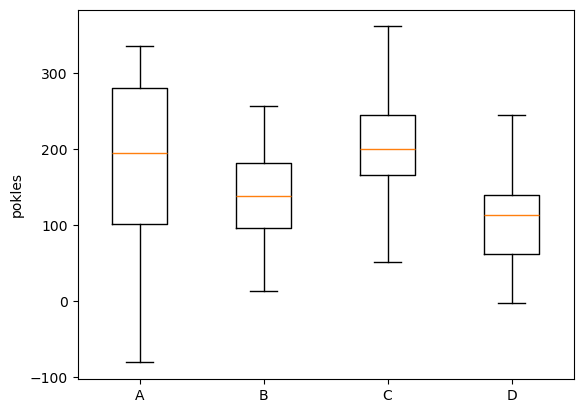

In [293]:
# explorační analýza pomocí krabicových grafů
plt.boxplot(sloupce, tick_labels=vyrobci)
plt.ylabel(sloupec)

Mezi výběry jsou podstatné rozdíly (např. mezi C a D, C a B, A a D). Předběžně lze očekávat, že střední hodnoty nejsou shodné.

### Ověření předpokladů

In [294]:
# oveřní normality jednolivých výberů pomocí Shapirova-Wilkova testu
aku[[sloupec, 'vyrobce']].groupby('vyrobce').apply(stats.shapiro)

vyrobce
C    (0.9771801984746905, 0.7305985157366341)
B    (0.9809904732653778, 0.8278426717530349)
A    (0.9489118504818493, 0.1580745817056497)
D    (0.9790966177238782, 0.7729256699958005)
dtype: object

POZOR: Pokud bychom celkovou hypotézu o normalitě všech výběrů zamítli, pokud alespoň jednou nastane p-hodnota<0.05, 
bude výsledná pravděpodobnost chyby 1. druhu výrazně větší než 0.05.
<br>
Vhodnějším postupem je např. testování reziduí.

In [295]:
rezidua = aku['pokles'] - aku.groupby('vyrobce')['pokles'].transform('mean')
stats.shapiro(rezidua)

ShapiroResult(statistic=np.float64(0.9883541850212082), pvalue=np.float64(0.36944508049695546))

P-hodnota jsou vyšší než 0.05. Hypotézu o normalitě nezamítáme.

In [296]:
sloupce

[array([279., -81., 106., 192.,  98.,  81.,  79., 158., 204., 100., 307.,
        163., 297., 317., 198., 288., 147., 210., 335., 107., 280., 241.,
        135., 255.,  92., 325., -10., 262.,  27., 296.]),
 array([ 13.,  52., 168., 119., 116.,  65., 190., 127., 255., 152.,  45.,
         88., 257.,  74., 222., 201., 201.,  31., 142.,  46., 109., 143.,
        143., 184., 171., 114., 188., 116., 135., 180., 170.,  99.]),
 array([190., 173., 107., 244., 245.,  57., 290., 306., 117., 297., 180.,
        158., 240., 214., 201., 153.,  66., 116., 285., 218.,  51., 225.,
        269., 193., 361., 199., 200., 174., 254., 202., 188.]),
 array([223., 128., 116., 165., 112.,  38., 129., 144.,  22., 115.,  48.,
         80.,  63.,  84., 130., 137.,  56.,  58., 174.,  36., 175.,  23.,
         97.,  73.,  -3., 147., 126., 244.,  73., 212., 101., 130.])]

In [297]:
# ověření shody rozptylů jednotivych výběrů pomocí Bartlettova testu.
stats.bartlett(*sloupce)

BartlettResult(statistic=np.float64(13.776323661244252), pvalue=np.float64(0.0032259783789587654))

P-hodnota 0.003 je nižší než 0.05. Na hladině významnosti 0.05 zamítáme nulovou hypotézu o shodě roztylů. <br>
Pro test rovnosti středních hodnot použijeme Welchovou ANOVu (pro výběry s nestejnými rozptyly).

Testujeme $H_0:\mu_1=\mu_2=\mu_3=\mu_4$ proti $H_1$: neplatí $H_0$.

In [298]:
res_anova = pingouin.welch_anova(aku, dv='pokles', between='vyrobce')
print(res_anova)

    Source  ddof1      ddof2          F     p_unc       np2
0  vyrobce      3  65.573207  10.800051  0.000007  0.184438


In [299]:
print("Welchova ANOVA: p-hodnota={:f}".format(res_anova['p_unc'][0]))

Welchova ANOVA: p-hodnota=0.000007


Na hladině významnosti 0.05 zamítáme $H_0$. Střední hodnoty nejsou shodné.

In [300]:
# post-hoc analýza (porovnání po dvojicích)
pingouin.pairwise_gameshowell(aku, dv='pokles', between='vyrobce')

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,C,B,199.129032,134.875000,64.254032,17.371595,3.698799,58.742698,0.002631,0.923062
1,C,A,199.129032,182.933333,16.195699,23.837432,0.679423,51.192166,0.904436,0.172817
2,C,D,199.129032,108.000000,91.129032,17.066894,5.339521,57.716163,0.000010,1.333435
3,B,A,134.875000,182.933333,-48.058333,22.672062,-2.119716,45.987274,0.162115,-0.540625
4,B,D,134.875000,108.000000,26.875000,15.397341,1.745431,61.878774,0.309472,0.431058
5,A,D,182.933333,108.000000,74.933333,22.439451,3.339357,44.753940,0.008900,0.852604


Statisticky významný rozdíl v poklesu kapacity je mezi dvojicemi výrobců (C, B), (C, D) a (A, D).

### Další možnosti vícenásobného porovnání stř. hodnot

In [301]:
# ANOVA pro výběry s nestejnými rozptyly
oneway.anova_oneway(aku[sloupec], aku['vyrobce'], use_var='unequal')

<class 'statsmodels.stats.base.HolderTuple'>
statistic = np.float64(10.800051345001934)
pvalue = np.float64(7.413729881250116e-06)
df = (3.0, np.float64(65.57320655986469))
df_num = 3.0
df_denom = np.float64(65.57320655986469)
nobs_t = np.float64(125.0)
n_groups = 4
means = array([182.93333333, 134.875     , 199.12903226, 108.        ])
nobs = array([30., 32., 31., 32.])
vars_ = array([11707.09885057,  3961.14516129,  5517.5827957 ,  3625.35483871])
use_var = 'unequal'
welch_correction = True
tuple = (np.float64(10.800051345001934), np.float64(7.413729881250116e-06))

In [302]:
# ANOVA pro věýběry se stejnými rozptyly (pomocí stats)
stats.f_oneway(*sloupce)

F_onewayResult(statistic=np.float64(9.121309719844383), pvalue=np.float64(1.7255975660772036e-05))

In [303]:
# ANOVA pro výběry se stejnými rozptyly  (pomocí pingouin)
pingouin.anova(aku, dv='pokles', between='vyrobce')

,Source,ddof1,ddof2,F,p_unc,np2
0,vyrobce,3,121,9.12131,0.000017,0.184438


In [304]:
# post-hoc analyza - porovnani str. hodnot jednotlivych dvojic pro stejné rozptyly
tukey_res = pairwise_tukeyhsd(aku[sloupec], aku['vyrobce'])
print(tukey_res)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     A      B -48.0583 0.0791  -99.8393   3.7226  False
     A      C  16.1957 0.8503  -35.9878  68.3792  False
     A      D -74.9333 0.0014 -126.7143 -23.1524   True
     B      C   64.254 0.0078    12.906 115.6021   True
     B      D  -26.875 0.5178  -77.8139  24.0639  False
     C      D  -91.129 0.0001 -142.4771  -39.781   True
-------------------------------------------------------


In [305]:
# Kruskalův-Wallisův test (alternatitva ANOVy pro případ, že výběry nepochází z normalního rozdělení)
#
# Kruskalův-Wallisův test ověřuje shodu rozdělení jednotlivých výběrů. 
# Jestliže rozdělení jednotlivých výběrů mají stejný "tvar" a mohou se lišit jen středními hodnotami (tj. jsou vzájemně posunuta o konstanty),
#    je nulová hypotéza o shodě rozdělení ekvivalentní hypotéze o rovnosti středních hodnot. 
# 
stats.kruskal(*sloupce)

KruskalResult(statistic=np.float64(24.17659825576398), pvalue=np.float64(2.2946586382520245e-05))

In [306]:
# post-hoc analyza pro Kruskaluv-Wallisuv test
sp.posthoc_dunn(sloupce)

NameError: name 'sp' is not defined

In [251]:
#%load_ext watermark
#%watermark --iversions

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
pingouin       : 0.5.1
numpy          : 1.21.3
scipy          : 1.7.1
statsmodels    : 0.13.2
matplotlib     : 3.4.3
scikit_posthocs: 0.7.0
pandas         : 1.3.4

